# EQPolarity-Torch: load pretrained models and plot confusion matrices

This is the **PyTorch replacement** for `run_eqpolarity_load_models_plot_confusion_matrix.ipynb`.
It keeps the original Texas data loading, class convention (`0=Up`, `1=Down`), threshold (`0.5`), metrics, output figure names, and confusion-matrix visualization style.

Install the new package first from the `eqpolarity-torch` repository:

```bash
python -m pip install -e .
```

The notebook lets you evaluate both the **California/SCSN pretrained model** and the **Texas 10% transfer-learning model** using the ported PyTorch checkpoints/weights.


In [1]:
# EQPolarity-Torch setup
from pathlib import Path
import numpy as np
import torch

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
)

from eqpolarity_torch import load_model, predict_proba

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("PyTorch:", torch.__version__)
print("Device :", DEVICE)

# These defaults match the repository layout when this notebook is under notebooks/.
DATA_DIR = Path("../data/TexasData")
MODEL_DIR = Path("../models")
if not MODEL_DIR.exists():
    # load_model() can resolve weights from an editable eqpolarity-torch checkout.
    MODEL_DIR = None


PyTorch: 2.10.0
Device : cpu


In [2]:
## Import data
# polall: Texas polarity labels (22980 x 1 in the original dataset)
# datall: 600-sample vertical-component waveforms centered on the analyst P arrival
#         (22980 x 600 x 1 in the original dataset)

polall = np.load(DATA_DIR / "polall_Texas.npy")

data = []
for ii in range(6):
    data.append(np.load(DATA_DIR / f"datall_Texas{ii+1}.npy"))
datall = np.concatenate(data, axis=0).astype(np.float32, copy=False)

# Keep sklearn labels one-dimensional while preserving the original 0=Up, 1=Down convention.
labtest = np.asarray(polall).reshape(-1).astype(np.int64)

print("datall:", datall.shape, datall.dtype)
print("polall:", polall.shape, polall.dtype)
print("N Up / Down:", np.bincount(labtest, minlength=2))


datall: (22980, 600, 1) float32
polall: (22980,) int64
N Up / Down: [14543  8437]


In [3]:
def model_summary(model):
    total = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(model)
    print(f"\nTotal parameters    : {total:,}")
    print(f"Trainable parameters: {trainable:,}")

# Load the original California/SCSN pretrained EQPolarity weights in PyTorch.
model = load_model("scsn", models_dir=MODEL_DIR, device=DEVICE)
model_summary(model)


EQPolarityCCT(
  (tokenizer): Tokenizer(
    (conv1): TFSameConv1d(
      (conv): Conv1d(1, 200, kernel_size=(4,), stride=(1,), bias=False)
    )
    (pool1): TFSameMaxPool1d()
    (conv2): TFSameConv1d(
      (conv): Conv1d(200, 200, kernel_size=(4,), stride=(1,), bias=False)
    )
    (pool2): TFSameMaxPool1d()
  )
  (blocks): ModuleList(
    (0-3): 4 x TransformerBlock(
      (norm1): LayerNorm((200,), eps=1e-05, elementwise_affine=True)
      (attn): KerasCompatibleMHA(
        (attn_dropout): Dropout(p=0.2, inplace=False)
      )
      (drop_path1): DropPath()
      (norm2): LayerNorm((200,), eps=1e-05, elementwise_affine=True)
      (fc1): Linear(in_features=200, out_features=200, bias=True)
      (fc2): Linear(in_features=200, out_features=200, bias=True)
      (dropout1): Dropout(p=0.2, inplace=False)
      (dropout2): Dropout(p=0.2, inplace=False)
      (drop_path2): DropPath()
    )
  )
  (final_norm): LayerNorm((200,), eps=1e-05, elementwise_affine=True)
  (final_dropout): D

In [4]:
def apply_threshold(probabilities, threshold=0.5):
    """EQPolarity convention: probability >= threshold -> Down (1), else Up (0)."""
    p = np.asarray(probabilities).reshape(-1)
    return (p >= threshold).astype(np.int64)


def report_metrics(y_true, y_pred):
    print("micro:")
    print(
        accuracy_score(y_true, y_pred),
        precision_score(y_true, y_pred, average="micro"),
        recall_score(y_true, y_pred, average="micro"),
        f1_score(y_true, y_pred, average="micro"),
    )
    print("\nper class [Up, Down]:")
    print(
        accuracy_score(y_true, y_pred),
        precision_score(y_true, y_pred, average=None),
        recall_score(y_true, y_pred, average=None),
        f1_score(y_true, y_pred, average=None),
    )
    print("\nmacro:")
    print(
        accuracy_score(y_true, y_pred),
        precision_score(y_true, y_pred, average="macro"),
        recall_score(y_true, y_pred, average="macro"),
        f1_score(y_true, y_pred, average="macro"),
    )


## 1. California/SCSN pretrained model on the Texas dataset


In [5]:
# PyTorch inference. The returned value is P(Down), equivalent to the original sigmoid output.
out = predict_proba(model, datall, batch_size=1024, device=DEVICE)
print("output:", out.shape, "range:", (float(out.min()), float(out.max())))


output: (22980,) range: (9.195775783155113e-05, 0.9999266862869263)


In [6]:
thre = 0.5
outtest = apply_threshold(out, thre)
report_metrics(labtest, outtest)


micro:
0.9459094865100087 0.9459094865100087 0.9459094865100087 0.9459094865100087

per class [Up, Down]:
0.9459094865100087 [0.97869277 0.89579665] [0.93488276 0.96491644] [0.95628627 0.92907275]

macro:
0.9459094865100087 0.937244713874233 0.9498996004793541 0.9426795100671326


In [7]:
cf_matrix = confusion_matrix(labtest, outtest)
print(cf_matrix)


[[13596   947]
 [  296  8141]]


In [8]:
# Same confusion-matrix visualization style as the original TensorFlow notebook/package.
def plot_confusionmatrix(cf=None, categories=("Up", "Down"),
                         figname="Conf_Matrix_before_transferlearning.png",
                         ifshow=True):
    import numpy as np
    import seaborn as sn
    import matplotlib.pyplot as plt

    font = {"family": "normal", "weight": "bold", "size": 16}
    plt.rc("font", **font)

    group_percentages = []
    counts = []
    for i in range(len(cf)):
        for j in range(len(cf)):
            group_percentages.append(cf[j, i] / np.sum(cf[:, i]))
            counts.append(cf[j, i])

    percentages_matrix = np.reshape(group_percentages, (2, 2))
    group_percentages = ["{0:.2%}".format(value) for value in group_percentages]
    labels = [f"{v1}\n{v2}" for v1, v2 in zip(group_percentages, counts)]
    labels = np.asarray(labels).reshape(2, 2, order="F")

    fig = plt.figure(figsize=(10, 7))
    sn.set(font_scale=2)
    sn.heatmap(
        percentages_matrix,
        annot=labels,
        fmt="",
        xticklabels=categories,
        yticklabels=categories,
        cbar=False,
    )
    fig.savefig(figname, bbox_inches="tight", transparent=True, dpi=100)
    if ifshow:
        plt.show()
    else:
        plt.close()
    return fig


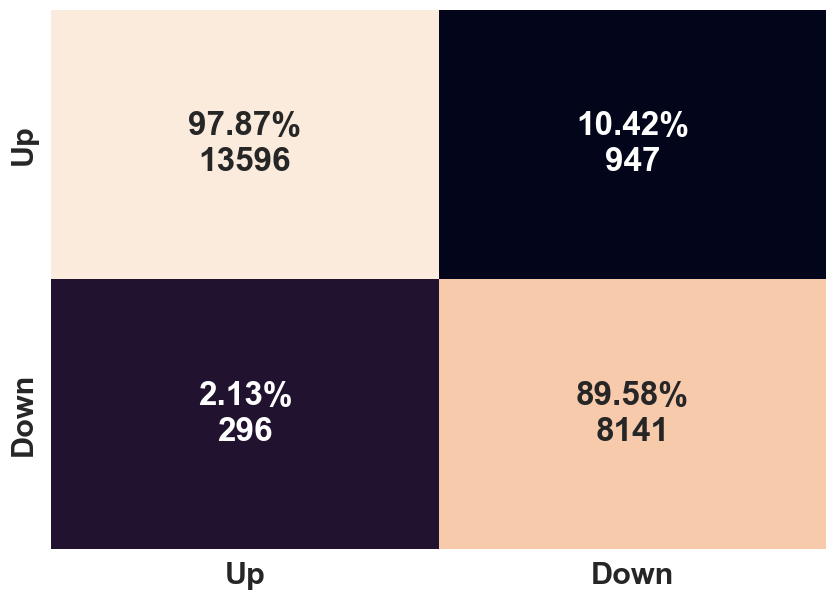

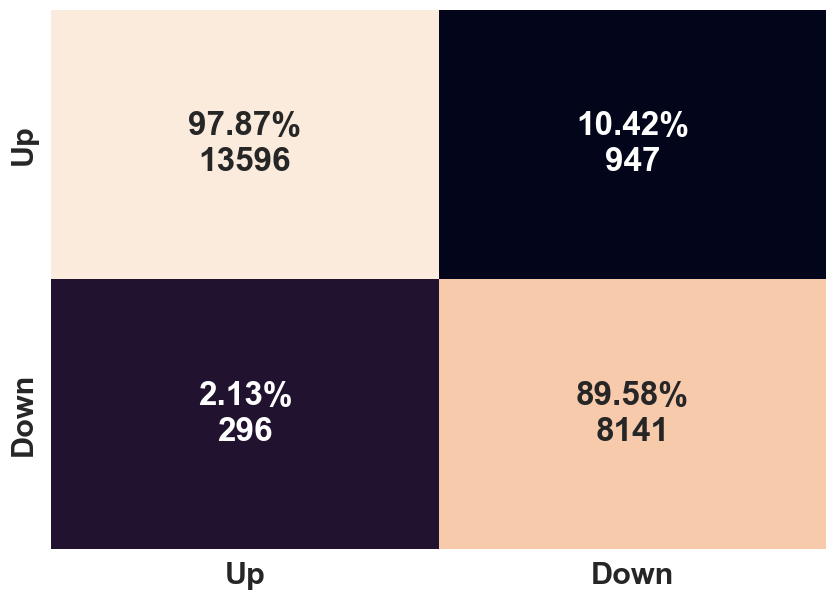

In [9]:
plot_confusionmatrix(
    cf=cf_matrix,
    categories=["Up", "Down"],
    figname="Conf_Matrix_before_transferlearning.png",
    ifshow=True,
)


## 2. Texas 10% transfer-learning model on the same dataset


In [10]:
# Select the Texas transfer-learning checkpoint.
model = load_model("texas", models_dir=MODEL_DIR, device=DEVICE)
out = predict_proba(model, datall, batch_size=1024, device=DEVICE)
print("output:", out.shape, "range:", (float(out.min()), float(out.max())))


output: (22980,) range: (2.044000038670113e-11, 0.9999997615814209)


In [11]:
thre = 0.5
outtest = apply_threshold(out, thre)
report_metrics(labtest, outtest)


micro:
0.9857267188859878 0.9857267188859878 0.9857267188859878 0.9857267188859878

per class [Up, Down]:
0.9857267188859878 [0.98912669 0.97987928] [0.98831053 0.98127296] [0.98871844 0.98057562]

macro:
0.9857267188859878 0.9845029851533673 0.9847917458626554 0.9846470336863404


In [12]:
cf_matrix = confusion_matrix(labtest, outtest)
print(cf_matrix)


[[14373   170]
 [  158  8279]]


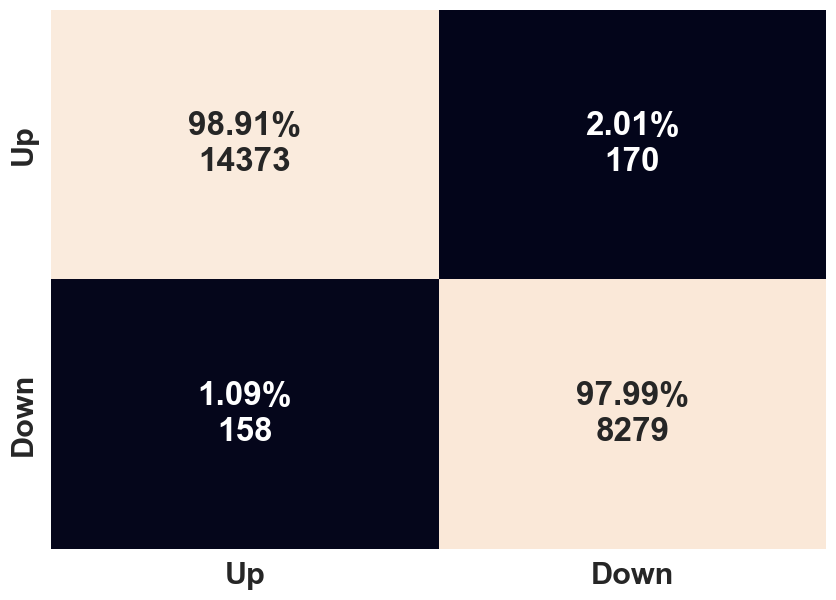

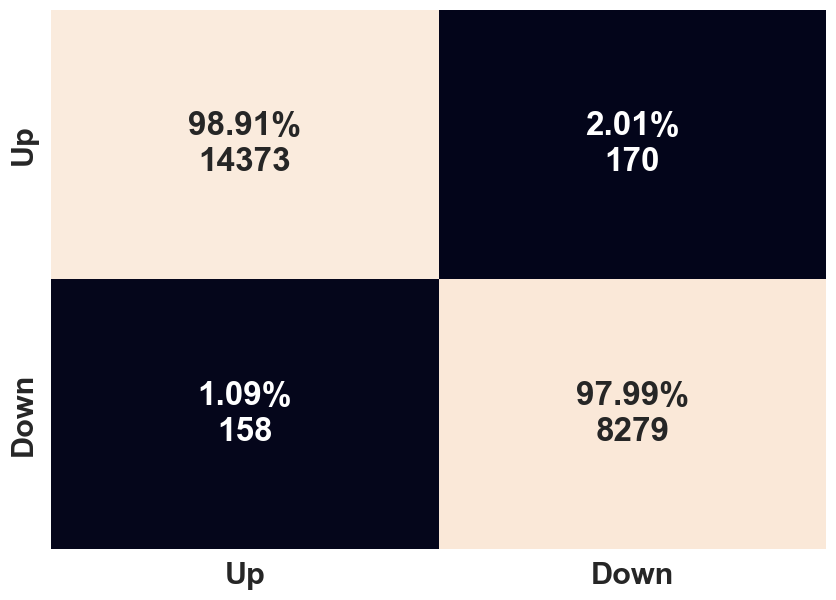

In [13]:
plot_confusionmatrix(
    cf=cf_matrix,
    categories=["Up", "Down"],
    figname="Conf_Matrix_after_transferlearning.png",
    ifshow=True,
)
